In [45]:
import torch
import torch.nn as nn
import numpy as np
import torchvision
import matplotlib.pyplot as plt

In [46]:
from torchvision import datasets
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader

In [47]:
from timeit import default_timer as timer

In [48]:
train_data = datasets.MNIST(root='data',train=True,download=True,transform=ToTensor(),target_transform=None)
test_data = datasets.MNIST(root='data',train=False,download=True,transform=ToTensor())

In [49]:
device= 'cpu'

In [50]:
img,label = train_data[0]
print(img)
print(label)

tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,

torch.Size([1, 28, 28])


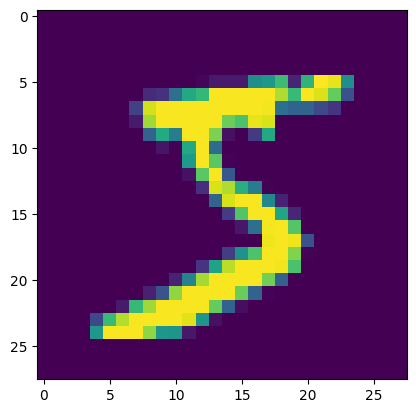

In [51]:
print(img.shape)
plt.imshow(img.squeeze())

In [52]:
print(len(train_data.data),len(train_data.targets),len(test_data.data),len(test_data.targets))

60000 60000 10000 10000


In [53]:
class_names = train_data.classes
print(class_names)

['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']


In [54]:
BATCH_SIZE = 32
train_dataloader = DataLoader(train_data,BATCH_SIZE,shuffle=True)
test_dataloader = DataLoader(test_data,BATCH_SIZE,shuffle=False)

In [55]:
print(len(train_dataloader))

1875


In [56]:
print(len(test_dataloader))

313


In [57]:
class MNISTModel(nn.Module):
  def __init__(self,input_shape,hidden_units,output_shape):
    super().__init__()
    self.block1 = nn.Sequential(
                  nn.Conv2d(in_channels=input_shape,out_channels=hidden_units,kernel_size=3,stride=1,padding=1),
                  nn.ReLU(),
                  nn.Conv2d(in_channels=hidden_units,out_channels=hidden_units,kernel_size=3,stride=1,padding=1),
                  nn.ReLU(),
                  nn.MaxPool2d(kernel_size=2,stride=2))
    self.block2 = nn.Sequential(
              nn.Conv2d(hidden_units,hidden_units,kernel_size=3,padding=1),
              nn.ReLU(),
              nn.Conv2d(in_channels=hidden_units,out_channels=hidden_units,kernel_size=3,padding=1),
              nn.ReLU(),
              nn.MaxPool2d(kernel_size=2,stride=2))
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=hidden_units*7*7,out_features=output_shape)
    )

  def forward(self,x):
    x = self.block1(x)
    x = self.block2(x)
    x = self.classifier(x)
    return x


In [58]:
torch.manual_seed(42)
model = MNISTModel(1,12,len(class_names)).to(device)

In [59]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model.parameters(),lr=0.1)

In [60]:
def accuracy_fn(y_pred,y_test):
  correct = torch.eq(y_pred,y_test).sum().item()
  return (correct*100)/len(y_test)

In [61]:
def train_step(model,data_loader,loss_fn,optimizer,accuracy_fn,device):
  train_loss,train_acc = 0,0
  model.to(device)
  model.train()
  for X,y in data_loader:
    X,y = X.to(device),y.to(device)
    y_logits = model(X)
    y_preds = y_logits.argmax(dim=1)
    loss = loss_fn(y_logits,y)
    train_loss += loss
    train_acc += accuracy_fn(y_preds,y)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

  train_loss /= len(data_loader)
  train_acc /= len(data_loader)
  print(f'Train loss: {train_loss} Train accuracy: {train_acc}')

In [62]:
def test_step(model,data_loader,loss_fn,accuracy_fn,device):
  test_loss,test_acc = 0,0
  model.to(device)
  model.eval()
  with torch.inference_mode():
    for X,y in data_loader:
      X,y = X.to(device),y.to(device)
      y_logits = model(X)
      test_loss += loss_fn(y_logits,y)
      y_preds = y_logits.argmax(dim=1)
      test_acc += accuracy_fn(y_preds,y)

    test_loss /= len(data_loader)
    test_acc /= len(data_loader)

  print(f"Test loss: {test_loss} Test acc: {test_acc}")

In [63]:
def eval_model(model,data_loader,loss_fn,accuracy_fn,device):
  test_loss,test_acc = 0,0
  model.eval()
  with torch.inference_mode():
    for X,y in data_loader:
      X,y = X.to(device),y.to(device)
      y_logits = model(X)
      y_preds = y_logits.argmax(dim=1)
      test_loss += loss_fn(y_logits,y)
      test_acc += accuracy_fn(y_preds,y)
    test_loss /= len(data_loader)
    test_acc /= len(data_loader)

  print(f"Loss: {test_loss} Accuracy: {test_acc}")

In [64]:
def print_train_time(start: float, end: float, device: torch.device = None):
    total_time = end - start
    print(f"Train time on {device}: {total_time:.3f} seconds")
    return total_time

In [65]:
train_time_start_model = timer()
torch.manual_seed(42)
epochs = 3
for epoch in range(epochs):
  print(f"Epoch:{epoch}")
  train_step(model,train_dataloader,loss_fn,optimizer,accuracy_fn,device)
  test_step(model,test_dataloader,loss_fn,accuracy_fn,device)
train_time_end_model = timer()
total_train_time_model = print_train_time(start=train_time_start_model,
                                           end=train_time_end_model,
                                           device=device)


Epoch:0
Train loss: 0.2823728919029236 Train accuracy: 90.65833333333333
Test loss: 0.0661654844880104 Test acc: 97.93330670926518
Epoch:1
Train loss: 0.06819605082273483 Train accuracy: 97.88666666666667
Test loss: 0.04875945299863815 Test acc: 98.46246006389777
Epoch:2
Train loss: 0.052605967968702316 Train accuracy: 98.35666666666667
Test loss: 0.050160396844148636 Test acc: 98.3626198083067
Train time on cpu: 116.202 seconds


In [66]:
eval_model(model,test_dataloader,loss_fn,accuracy_fn,device)

Loss: 0.050160396844148636 Accuracy: 98.3626198083067


In [67]:
y_preds = []
with torch.inference_mode():
  for X,y in test_dataloader:
    X,y = X.to(device),y.to(device)
    y_logits = model(X)
    y_pred = torch.softmax(y_logits,dim=1).argmax(dim=1)
    y_preds.append(y_pred.cpu())
y_preds_tensor = torch.cat(y_preds)

In [68]:
pip install torchmetrics

In [69]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

In [70]:
confmat = ConfusionMatrix(num_classes = len(class_names),task='multiclass')
confmat_tensor = confmat(preds=y_preds_tensor,target=test_data.targets)

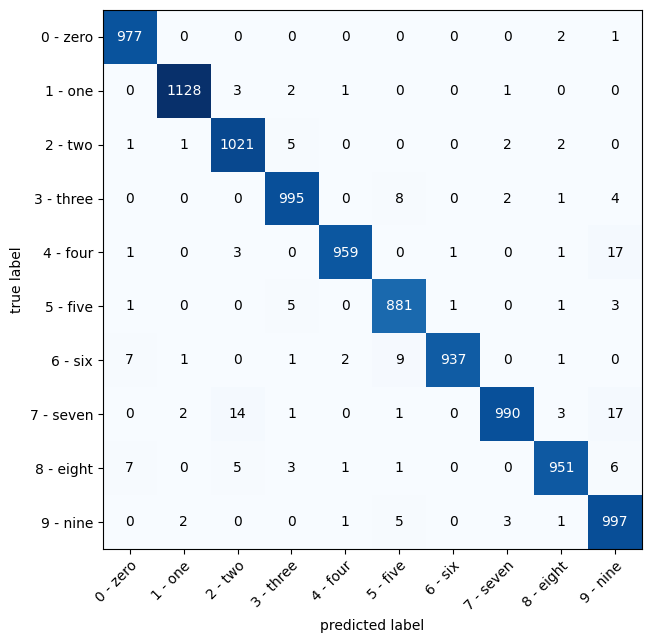

In [71]:
fig,ax = plot_confusion_matrix(conf_mat=confmat_tensor.numpy(),class_names=class_names,figsize=(10,7))